# CHIS 2024: Artificial Neural Network Models

Artificial neural networks are used for both project outcomes: chronic risk-factor control and the number of doctor visits in the past 12 months. Both models use the same 11,700-person modeling cohort and fixed 80/20 train/test split prepared in the shared cleaning workflow.

Two predictor sets are compared. The base set contains 17 demographic, socioeconomic, health, behavioral, and condition-profile variables. The expanded set contains the same 17 predictors plus seven insurance and healthcare-access variables, for 24 predictors total.

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf

from google.colab import drive

tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

## Shared data

The training and test files come from the completed team cleaning workflow. The modeling cohort contains 11,700 adults, with 9,360 respondents in training and 2,340 in the held-out test set. The original split is preserved so every model family uses the same respondents for training and final evaluation.

In [2]:
drive.mount('/content/drive')

data_path = '/content/drive/MyDrive/ml_healthcare_project/data/'

train = pd.read_csv(data_path + 'CHIS_2024_train.csv')
test = pd.read_csv(data_path + 'CHIS_2024_test.csv')

Mounted at /content/drive


In [3]:
print("Train:", train.shape)
print("Test:", test.shape)
print("Missing train values:", train.isna().sum().sum())
print("Missing test values:", test.isna().sum().sum())

Train: (9360, 29)
Test: (2340, 29)
Missing train values: 0
Missing test values: 0


## ANN classification

The classification model predicts whether CHIS-defined chronic risk factors were not controlled. `not_controlled = 1` is the positive class.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [5]:
base_predictors = [
    'srage_p1',
    'srsex',
    'racehp2_p1',
    'ur_clrt4',
    'sreduc',
    'wrkst_p1',
    'stablehouse',
    'ab1',
    'ac212',
    'smkcur',
    'ab17',
    'diabetes',
    'ab29v2',
    'ab34',
    'ac6v2',
    'povll2_p1v2',
    'bmi_p'
]

access_predictors = [
    'instype',
    'coverage_continuity',
    'usual',
    'ah81b',
    'ah22',
    'pc_ins',
    'aj218'
]

expanded_predictors = base_predictors + access_predictors

predictor_labels = {
    'srage_p1': 'Age',
    'srsex': 'Gender',
    'racehp2_p1': 'Race/ethnicity',
    'ur_clrt4': 'Urban/rural',
    'sreduc': 'Education',
    'wrkst_p1': 'Employment status',
    'stablehouse': 'Stable housing',
    'ab1': 'General health',
    'ac212': 'Physical activity',
    'smkcur': 'Current smoking',
    'ab17': 'Asthma',
    'diabetes': 'Diabetes',
    'ab29v2': 'High blood pressure',
    'ab34': 'Heart disease',
    'ac6v2': 'Stroke',
    'povll2_p1v2': 'Poverty ratio',
    'bmi_p': 'BMI',
    'instype': 'Insurance type',
    'coverage_continuity': 'Coverage continuity',
    'usual': 'Usual place for healthcare',
    'ah81b': 'Medical-bill problems',
    'ah22': 'Delayed or missed needed medical care',
    'pc_ins': 'Difficulty finding a PCP accepting insurance',
    'aj218': 'Ease of getting needed care'
}

print("Base predictors:", len(base_predictors))
print("Expanded predictors:", len(expanded_predictors))

Base predictors: 17
Expanded predictors: 24


In [6]:
X_train_base = train[base_predictors].copy()
X_test_base = test[base_predictors].copy()

X_train_expanded = train[expanded_predictors].copy()
X_test_expanded = test[expanded_predictors].copy()

y_train = train['not_controlled'].copy()
y_test = test['not_controlled'].copy()

print("Base:", X_train_base.shape, X_test_base.shape)
print("Expanded:", X_train_expanded.shape, X_test_expanded.shape)

Base: (9360, 17) (2340, 17)
Expanded: (9360, 24) (2340, 24)


In [7]:

print(y_train.value_counts().sort_index())
print()
print(y_train.value_counts(normalize=True).sort_index())

not_controlled
0    6848
1    2512
Name: count, dtype: int64

not_controlled
0    0.731624
1    0.268376
Name: proportion, dtype: float64


### Predictor preparation

Age, poverty level relative to the Federal Poverty Level, and BMI are treated as numeric variables. They are standardized within the training data. The remaining predictors are categorical and are one-hot encoded.

The same preprocessing rules are used for both predictor sets. The expanded set differs only by adding the seven insurance and healthcare-access variables.

In [8]:
num_cols = [
    'srage_p1',
    'povll2_p1v2',
    'bmi_p'
]

base_cat_cols = [
    'srsex',
    'racehp2_p1',
    'ur_clrt4',
    'sreduc',
    'wrkst_p1',
    'stablehouse',
    'ab1',
    'ac212',
    'smkcur',
    'ab17',
    'diabetes',
    'ab29v2',
    'ab34',
    'ac6v2'
]

access_cat_cols = [
    'instype',
    'coverage_continuity',
    'usual',
    'ah81b',
    'ah22',
    'pc_ins',
    'aj218'
]

expanded_cat_cols = base_cat_cols + access_cat_cols

print("Base numeric:", len(num_cols))
print("Base categorical:", len(base_cat_cols))
print("Expanded categorical:", len(expanded_cat_cols))

def make_preprocessor(cat_cols):
    return ColumnTransformer(
        transformers=[
            (
                'num',
                StandardScaler(),
                num_cols
            ),
            (
                'cat',
                OneHotEncoder(
                    handle_unknown='ignore',
                    sparse_output=False
                ),
                cat_cols
            )
        ]
    )

Base numeric: 3
Base categorical: 14
Expanded categorical: 21


### Baseline cross-validation

The first classification comparison uses five stratified folds. The same training and validation respondents are used for the base and expanded predictor sets within every fold. Preprocessing is fit only on the training portion of each fold before the corresponding validation data are transformed.

Both models use the same ANN structure and training settings so the comparison isolates the addition of the insurance and healthcare-access variables.

In [9]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

In [10]:
def build_classifier(
    n_features,
    layers=(32, 16),
    learning_rate=0.001
):
    tf.keras.utils.set_random_seed(42)

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(n_features,)))

    for units in layers:
        model.add(tf.keras.layers.Dense(units, activation='relu'))

    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy'
    )

    return model

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
folds = list(cv.split(X_train_base, y_train))

base_scores = []
expanded_scores = []

for fold, (train_idx, val_idx) in enumerate(folds, 1):
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    base_prep = make_preprocessor(base_cat_cols)

    X_base_train = base_prep.fit_transform(
        X_train_base.iloc[train_idx]
    )
    X_base_val = base_prep.transform(
        X_train_base.iloc[val_idx]
    )

    tf.keras.backend.clear_session()

    base_model = build_classifier(X_base_train.shape[1])

    base_model.fit(
        X_base_train,
        y_fold_train,
        epochs=30,
        batch_size=32,
        verbose=0
    )

    base_prob = base_model.predict(X_base_val, verbose=0).ravel()
    base_pred = (base_prob >= 0.5).astype(int)

    base_scores.append([
        precision_score(y_fold_val, base_pred),
        recall_score(y_fold_val, base_pred),
        f1_score(y_fold_val, base_pred),
        roc_auc_score(y_fold_val, base_prob),
        average_precision_score(y_fold_val, base_prob)
    ])

    expanded_prep = make_preprocessor(expanded_cat_cols)

    X_expanded_train = expanded_prep.fit_transform(
        X_train_expanded.iloc[train_idx]
    )
    X_expanded_val = expanded_prep.transform(
        X_train_expanded.iloc[val_idx]
    )

    tf.keras.backend.clear_session()

    expanded_model = build_classifier(X_expanded_train.shape[1])

    expanded_model.fit(
        X_expanded_train,
        y_fold_train,
        epochs=30,
        batch_size=32,
        verbose=0
    )

    expanded_prob = expanded_model.predict(
        X_expanded_val,
        verbose=0
    ).ravel()

    expanded_pred = (expanded_prob >= 0.5).astype(int)

    expanded_scores.append([
        precision_score(y_fold_val, expanded_pred),
        recall_score(y_fold_val, expanded_pred),
        f1_score(y_fold_val, expanded_pred),
        roc_auc_score(y_fold_val, expanded_prob),
        average_precision_score(y_fold_val, expanded_prob)
    ])

    print("Fold", fold, "complete")

Fold 1 complete
Fold 2 complete
Fold 3 complete
Fold 4 complete
Fold 5 complete


In [12]:
base_cv_results = pd.DataFrame(
    base_scores,
    columns=['Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC'],
    index=range(1, 6)
)

expanded_cv_results = pd.DataFrame(
    expanded_scores,
    columns=['Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC'],
    index=range(1, 6)
)

base_cv_results.index.name = 'Fold'
expanded_cv_results.index.name = 'Fold'

print("Base")
print(base_cv_results.round(3))
print()
print("Expanded")
print(expanded_cv_results.round(3))
print()

baseline_means = pd.DataFrame({
    'Base': base_cv_results.mean(),
    'Expanded': expanded_cv_results.mean()
}).T

print("Mean comparison")
print(baseline_means.round(3))

Base
      Precision  Recall     F1  ROC-AUC  PR-AUC
Fold                                           
1         0.447   0.250  0.321    0.687   0.440
2         0.522   0.282  0.366    0.695   0.455
3         0.526   0.301  0.383    0.707   0.483
4         0.553   0.209  0.303    0.717   0.465
5         0.489   0.325  0.390    0.710   0.466

Expanded
      Precision  Recall     F1  ROC-AUC  PR-AUC
Fold                                           
1         0.506   0.400  0.447    0.702   0.479
2         0.538   0.284  0.372    0.698   0.471
3         0.519   0.402  0.453    0.713   0.497
4         0.560   0.289  0.381    0.713   0.492
5         0.508   0.380  0.435    0.709   0.466

Mean comparison
          Precision  Recall     F1  ROC-AUC  PR-AUC
Base          0.507   0.273  0.353    0.703   0.462
Expanded      0.526   0.351  0.418    0.707   0.481


### Classification refinement

The expanded baseline produced higher mean recall, F1, and PR-AUC than the base model under the same five folds and ANN settings. Recall remained relatively low for both predictor sets, which is relevant because `not_controlled = 1` is the less common class.

Class weighting is evaluated next. Within each training fold, weights are calculated from that fold's class counts. Base and expanded models use the same weights, training and validation respondents, ANN structure, and 0.50 classification threshold.

In [13]:
base_weighted_scores = []
expanded_weighted_scores = []

for fold, (train_idx, val_idx) in enumerate(folds, 1):
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    counts = y_fold_train.value_counts()

    weights = {
        0: len(y_fold_train) / (2 * counts[0]),
        1: len(y_fold_train) / (2 * counts[1])
    }

    base_prep = make_preprocessor(base_cat_cols)

    X_base_train = base_prep.fit_transform(
        X_train_base.iloc[train_idx]
    )
    X_base_val = base_prep.transform(
        X_train_base.iloc[val_idx]
    )

    tf.keras.backend.clear_session()

    base_model = build_classifier(X_base_train.shape[1])

    base_model.fit(
        X_base_train,
        y_fold_train,
        epochs=30,
        batch_size=32,
        class_weight=weights,
        verbose=0
    )

    base_prob = base_model.predict(X_base_val, verbose=0).ravel()
    base_pred = (base_prob >= 0.5).astype(int)

    base_weighted_scores.append([
        precision_score(y_fold_val, base_pred),
        recall_score(y_fold_val, base_pred),
        f1_score(y_fold_val, base_pred),
        roc_auc_score(y_fold_val, base_prob),
        average_precision_score(y_fold_val, base_prob)
    ])

    expanded_prep = make_preprocessor(expanded_cat_cols)

    X_expanded_train = expanded_prep.fit_transform(
        X_train_expanded.iloc[train_idx]
    )
    X_expanded_val = expanded_prep.transform(
        X_train_expanded.iloc[val_idx]
    )

    tf.keras.backend.clear_session()

    expanded_model = build_classifier(X_expanded_train.shape[1])

    expanded_model.fit(
        X_expanded_train,
        y_fold_train,
        epochs=30,
        batch_size=32,
        class_weight=weights,
        verbose=0
    )

    expanded_prob = expanded_model.predict(
        X_expanded_val,
        verbose=0
    ).ravel()

    expanded_pred = (expanded_prob >= 0.5).astype(int)

    expanded_weighted_scores.append([
        precision_score(y_fold_val, expanded_pred),
        recall_score(y_fold_val, expanded_pred),
        f1_score(y_fold_val, expanded_pred),
        roc_auc_score(y_fold_val, expanded_prob),
        average_precision_score(y_fold_val, expanded_prob)
    ])

    print("Fold", fold, "complete")

Fold 1 complete
Fold 2 complete
Fold 3 complete
Fold 4 complete
Fold 5 complete


In [14]:
base_weighted_results = pd.DataFrame(
    base_weighted_scores,
    columns=['Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC'],
    index=range(1, 6)
)

expanded_weighted_results = pd.DataFrame(
    expanded_weighted_scores,
    columns=['Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC'],
    index=range(1, 6)
)

base_weighted_results.index.name = 'Fold'
expanded_weighted_results.index.name = 'Fold'

print("Base")
print(base_weighted_results.round(3))
print()
print("Expanded")
print(expanded_weighted_results.round(3))
print()

weighted_means = pd.DataFrame({
    'Base': base_weighted_results.mean(),
    'Expanded': expanded_weighted_results.mean()
}).T

print("Mean comparison")
print(weighted_means.round(3))

Base
      Precision  Recall     F1  ROC-AUC  PR-AUC
Fold                                           
1         0.394   0.658  0.493    0.699   0.454
2         0.412   0.575  0.480    0.682   0.437
3         0.431   0.635  0.514    0.709   0.493
4         0.435   0.602  0.505    0.712   0.461
5         0.415   0.703  0.522    0.716   0.470

Expanded
      Precision  Recall     F1  ROC-AUC  PR-AUC
Fold                                           
1         0.408   0.680  0.510    0.697   0.460
2         0.425   0.493  0.456    0.687   0.465
3         0.396   0.594  0.475    0.688   0.466
4         0.428   0.536  0.476    0.710   0.486
5         0.432   0.653  0.520    0.713   0.461

Mean comparison
          Precision  Recall     F1  ROC-AUC  PR-AUC
Base          0.417   0.635  0.503    0.703   0.463
Expanded      0.418   0.591  0.487    0.699   0.468


Class weighting increased recall and F1 for both predictor sets. Mean F1 increased from 0.353 to 0.503 for the base set and from 0.418 to 0.487 for the expanded set. The weighted base model had the higher mean F1, while the expanded model retained a small advantage in PR-AUC.

Because `not_controlled = 1` is the less common class and weighting substantially improved recall and F1, class weighting is retained for hyperparameter tuning. Both predictor sets continue to tuning before either is selected.

### Classification tuning

Network structure, Adam learning rate, and batch size are compared using the same five stratified folds for both predictor sets. Class weighting is retained, and all other training settings remain unchanged.

Mean F1 is used to compare configurations. The held-out test set remains untouched during tuning and model selection.

In [15]:
settings = [
    ((16, 8), 0.001, 32),
    ((16, 8), 0.0001, 32),
    ((16, 8), 0.01, 32),
    ((16, 8), 0.001, 16),
    ((16, 8), 0.001, 64),
    ((32, 16), 0.001, 32),
    ((64, 32), 0.001, 32),
    ((64, 32, 16), 0.001, 32)
]

base_tuning = []
expanded_tuning = []

for layers, learning_rate, batch_size in settings:
    base_fold_scores = []
    expanded_fold_scores = []

    for train_idx, val_idx in folds:
        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]

        counts = y_fold_train.value_counts()

        weights = {
            0: len(y_fold_train) / (2 * counts[0]),
            1: len(y_fold_train) / (2 * counts[1])
        }

        base_prep = make_preprocessor(base_cat_cols)

        X_base_train = base_prep.fit_transform(
            X_train_base.iloc[train_idx]
        )
        X_base_val = base_prep.transform(
            X_train_base.iloc[val_idx]
        )

        tf.keras.backend.clear_session()

        base_model = build_classifier(
            X_base_train.shape[1],
            layers,
            learning_rate
        )

        base_model.fit(
            X_base_train,
            y_fold_train,
            epochs=30,
            batch_size=batch_size,
            class_weight=weights,
            verbose=0
        )

        base_prob = base_model.predict(
            X_base_val,
            verbose=0
        ).ravel()

        base_pred = (base_prob >= 0.5).astype(int)

        base_fold_scores.append(
            f1_score(y_fold_val, base_pred)
        )

        expanded_prep = make_preprocessor(expanded_cat_cols)

        X_expanded_train = expanded_prep.fit_transform(
            X_train_expanded.iloc[train_idx]
        )
        X_expanded_val = expanded_prep.transform(
            X_train_expanded.iloc[val_idx]
        )

        tf.keras.backend.clear_session()

        expanded_model = build_classifier(
            X_expanded_train.shape[1],
            layers,
            learning_rate
        )

        expanded_model.fit(
            X_expanded_train,
            y_fold_train,
            epochs=30,
            batch_size=batch_size,
            class_weight=weights,
            verbose=0
        )

        expanded_prob = expanded_model.predict(
            X_expanded_val,
            verbose=0
        ).ravel()

        expanded_pred = (expanded_prob >= 0.5).astype(int)

        expanded_fold_scores.append(
            f1_score(y_fold_val, expanded_pred)
        )

    base_tuning.append([
        str(layers),
        learning_rate,
        batch_size,
        np.mean(base_fold_scores)
    ])

    expanded_tuning.append([
        str(layers),
        learning_rate,
        batch_size,
        np.mean(expanded_fold_scores)
    ])

    print(layers, learning_rate, batch_size, "complete")

(16, 8) 0.001 32 complete
(16, 8) 0.0001 32 complete
(16, 8) 0.01 32 complete
(16, 8) 0.001 16 complete
(16, 8) 0.001 64 complete
(32, 16) 0.001 32 complete
(64, 32) 0.001 32 complete
(64, 32, 16) 0.001 32 complete


In [16]:
base_tuning_df = pd.DataFrame(
    base_tuning,
    columns=['Layers', 'Learning Rate', 'Batch Size', 'Mean F1']
)

expanded_tuning_df = pd.DataFrame(
    expanded_tuning,
    columns=['Layers', 'Learning Rate', 'Batch Size', 'Mean F1']
)

print("Base")
print(base_tuning_df.round({
    'Learning Rate': 4,
    'Mean F1': 3
}))
print()
print("Expanded")
print(expanded_tuning_df.round({
    'Learning Rate': 4,
    'Mean F1': 3
}))

Base
         Layers  Learning Rate  Batch Size  Mean F1
0       (16, 8)         0.0010          32    0.514
1       (16, 8)         0.0001          32    0.509
2       (16, 8)         0.0100          32    0.493
3       (16, 8)         0.0010          16    0.513
4       (16, 8)         0.0010          64    0.518
5      (32, 16)         0.0010          32    0.503
6      (64, 32)         0.0010          32    0.470
7  (64, 32, 16)         0.0010          32    0.471

Expanded
         Layers  Learning Rate  Batch Size  Mean F1
0       (16, 8)         0.0010          32    0.510
1       (16, 8)         0.0001          32    0.514
2       (16, 8)         0.0100          32    0.496
3       (16, 8)         0.0010          16    0.504
4       (16, 8)         0.0010          64    0.507
5      (32, 16)         0.0010          32    0.487
6      (64, 32)         0.0010          32    0.462
7  (64, 32, 16)         0.0010          32    0.445


The base predictor set produced the highest mean F1 across the tuned configurations. The selected ANN uses a 16–8 hidden-layer structure, a learning rate of 0.001, a batch size of 64, and class weighting.

Mean F1 was 0.518 for the selected base configuration and 0.514 for the best expanded configuration. Because the additional insurance and healthcare-access predictors did not improve the tuning result, the 17-predictor base set is carried forward. The selected configuration is evaluated across the same five training folds using the full classification metric set before final testing.

In [17]:
selected_scores = []

for fold, (train_idx, val_idx) in enumerate(folds, 1):
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    counts = y_fold_train.value_counts()

    weights = {
        0: len(y_fold_train) / (2 * counts[0]),
        1: len(y_fold_train) / (2 * counts[1])
    }

    fold_prep = make_preprocessor(base_cat_cols)

    X_fold_train = fold_prep.fit_transform(
        X_train_base.iloc[train_idx]
    )
    X_fold_val = fold_prep.transform(
        X_train_base.iloc[val_idx]
    )

    tf.keras.backend.clear_session()

    model = build_classifier(
        X_fold_train.shape[1],
        layers=(16, 8),
        learning_rate=0.001
    )

    model.fit(
        X_fold_train,
        y_fold_train,
        epochs=30,
        batch_size=64,
        class_weight=weights,
        verbose=0
    )

    prob = model.predict(X_fold_val, verbose=0).ravel()
    pred = (prob >= 0.5).astype(int)

    selected_scores.append([
        precision_score(y_fold_val, pred),
        recall_score(y_fold_val, pred),
        f1_score(y_fold_val, pred),
        roc_auc_score(y_fold_val, prob),
        average_precision_score(y_fold_val, prob)
    ])

    print("Fold", fold, "complete")

Fold 1 complete
Fold 2 complete
Fold 3 complete
Fold 4 complete
Fold 5 complete


In [18]:
selected_cv_results = pd.DataFrame(
    selected_scores,
    columns=['Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC'],
    index=range(1, 6)
)

selected_cv_results.index.name = 'Fold'

print(selected_cv_results.round(3))
print()
print("Mean")
print(selected_cv_results.mean().round(3))

      Precision  Recall     F1  ROC-AUC  PR-AUC
Fold                                           
1         0.421   0.680  0.520    0.717   0.461
2         0.415   0.642  0.504    0.703   0.465
3         0.414   0.631  0.500    0.713   0.488
4         0.436   0.727  0.545    0.733   0.493
5         0.414   0.707  0.522    0.733   0.500

Mean
Precision    0.420
Recall       0.678
F1           0.518
ROC-AUC      0.720
PR-AUC       0.482
dtype: float64


Across the five training folds, the selected ANN achieved a mean F1 of 0.518, with mean recall of 0.678. Mean ROC-AUC was 0.720 and mean PR-AUC was 0.482.

Performance was reasonably consistent across folds, with F1 ranging from 0.500 to 0.545. The model maintained higher recall than precision, which reflects the class weighting used to improve detection of the less common not-controlled group.

In [19]:
prep = make_preprocessor(base_cat_cols)

X_train_prep = prep.fit_transform(X_train_base)
X_test_prep = prep.transform(X_test_base)

counts = y_train.value_counts()

weights = {
    0: len(y_train) / (2 * counts[0]),
    1: len(y_train) / (2 * counts[1])
}

tf.keras.backend.clear_session()

selected_classifier = build_classifier(
    X_train_prep.shape[1],
    layers=(16, 8),
    learning_rate=0.001
)

history = selected_classifier.fit(
    X_train_prep,
    y_train,
    epochs=30,
    batch_size=64,
    class_weight=weights,
    verbose=0
)

In [20]:
test_prob = selected_classifier.predict(
    X_test_prep,
    verbose=0
).ravel()

test_pred = (test_prob >= 0.5).astype(int)

print("Precision:", round(precision_score(y_test, test_pred), 3))
print("Recall:", round(recall_score(y_test, test_pred), 3))
print("F1:", round(f1_score(y_test, test_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, test_prob), 3))
print("PR-AUC:", round(average_precision_score(y_test, test_prob), 3))

Precision: 0.409
Recall: 0.642
F1: 0.5
ROC-AUC: 0.703
PR-AUC: 0.464


In [21]:
test_cm = confusion_matrix(y_test, test_pred)

cm_table = pd.DataFrame(
    test_cm,
    index=[
        'Actual controlled',
        'Actual not controlled'
    ],
    columns=[
        'Predicted controlled',
        'Predicted not controlled'
    ]
)

print(cm_table)

                       Predicted controlled  Predicted not controlled
Actual controlled                      1130                       582
Actual not controlled                   225                       403


### Final classification results

On the held-out test set, the selected ANN achieved a precision of 0.409, recall of 0.642, and F1 score of 0.500 for the not-controlled class. ROC-AUC was 0.703 and PR-AUC was 0.464.

The model correctly identified 403 of the 628 adults whose chronic risk factors were not controlled and missed 225. It also correctly classified 1,130 controlled cases, while 582 controlled cases were predicted as not controlled. The higher recall than precision reflects the class weighting used to improve detection of the less common positive class.

In [22]:
X_train_reg_base = train[base_predictors].copy()
X_test_reg_base = test[base_predictors].copy()

X_train_reg_expanded = train[expanded_predictors].copy()
X_test_reg_expanded = test[expanded_predictors].copy()

y_train_reg = train['ah5'].copy()
y_test_reg = test['ah5'].copy()

print(y_train_reg.describe())

count    9360.000000
mean        5.722222
std         9.453288
min         0.000000
25%         2.000000
50%         4.000000
75%         6.000000
max       300.000000
Name: ah5, dtype: float64


### Regression cross-validation

The regression ANN predicts the number of doctor visits reported in the past 12 months. Base and expanded predictor sets are compared using the same five training folds.

Preprocessing is fit only on the training portion of each fold. MAE measures the average absolute prediction error in visits, RMSE gives greater weight to larger errors, and R² measures the amount of variation explained by the model.

In [23]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [24]:
def build_regressor(
    n_features,
    layers=(32, 16),
    learning_rate=0.001,
    loss='mean_squared_error'
):
    tf.keras.utils.set_random_seed(42)

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(n_features,)))

    for units in layers:
        model.add(tf.keras.layers.Dense(units, activation='relu'))

    model.add(tf.keras.layers.Dense(1))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=loss
    )

    return model

In [25]:
cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)
reg_folds = list(cv_reg.split(X_train_reg_base))

base_reg_scores = []
expanded_reg_scores = []

for fold, (train_idx, val_idx) in enumerate(reg_folds, 1):
    y_fold_train = y_train_reg.iloc[train_idx]
    y_fold_val = y_train_reg.iloc[val_idx]

    base_prep = make_preprocessor(base_cat_cols)

    X_base_train = base_prep.fit_transform(
        X_train_reg_base.iloc[train_idx]
    )
    X_base_val = base_prep.transform(
        X_train_reg_base.iloc[val_idx]
    )

    tf.keras.backend.clear_session()

    base_model = build_regressor(X_base_train.shape[1])

    base_model.fit(
        X_base_train,
        y_fold_train,
        epochs=30,
        batch_size=32,
        verbose=0
    )

    base_pred = base_model.predict(
        X_base_val,
        verbose=0
    ).ravel()

    base_reg_scores.append([
        mean_absolute_error(y_fold_val, base_pred),
        np.sqrt(mean_squared_error(y_fold_val, base_pred)),
        r2_score(y_fold_val, base_pred)
    ])

    expanded_prep = make_preprocessor(expanded_cat_cols)

    X_expanded_train = expanded_prep.fit_transform(
        X_train_reg_expanded.iloc[train_idx]
    )
    X_expanded_val = expanded_prep.transform(
        X_train_reg_expanded.iloc[val_idx]
    )

    tf.keras.backend.clear_session()

    expanded_model = build_regressor(X_expanded_train.shape[1])

    expanded_model.fit(
        X_expanded_train,
        y_fold_train,
        epochs=30,
        batch_size=32,
        verbose=0
    )

    expanded_pred = expanded_model.predict(
        X_expanded_val,
        verbose=0
    ).ravel()

    expanded_reg_scores.append([
        mean_absolute_error(y_fold_val, expanded_pred),
        np.sqrt(mean_squared_error(y_fold_val, expanded_pred)),
        r2_score(y_fold_val, expanded_pred)
    ])

    print("Fold", fold, "complete")

Fold 1 complete
Fold 2 complete
Fold 3 complete
Fold 4 complete
Fold 5 complete


In [26]:
base_reg_results = pd.DataFrame(
    base_reg_scores,
    columns=['MAE', 'RMSE', 'R²'],
    index=range(1, 6)
)

expanded_reg_results = pd.DataFrame(
    expanded_reg_scores,
    columns=['MAE', 'RMSE', 'R²'],
    index=range(1, 6)
)

base_reg_results.index.name = 'Fold'
expanded_reg_results.index.name = 'Fold'

print("Base")
print(base_reg_results.round(3))
print()
print("Expanded")
print(expanded_reg_results.round(3))
print()

reg_baseline_means = pd.DataFrame({
    'Base': base_reg_results.mean(),
    'Expanded': expanded_reg_results.mean()
}).T

print("Mean comparison")
print(reg_baseline_means.round(3))

Base
        MAE    RMSE     R²
Fold                      
1     4.662   9.430  0.038
2     4.556   9.554  0.067
3     4.312   7.994  0.046
4     4.597  11.312 -0.016
5     4.357   7.816  0.038

Expanded
        MAE    RMSE     R²
Fold                      
1     4.641   9.506  0.022
2     4.530   9.611  0.056
3     4.224   7.773  0.098
4     4.586  11.362 -0.025
5     4.206   7.822  0.037

Mean comparison
            MAE   RMSE     R²
Base      4.497  9.221  0.035
Expanded  4.437  9.215  0.038


### Regression cross-validation results

The expanded predictor set had slightly lower mean error in the baseline comparison. Mean MAE was 4.437 visits for the expanded model and 4.497 for the base model, while mean RMSE was nearly the same. Both models had low R² values, indicating that the baseline ANN explained little of the variation in doctor visits.

Both predictor sets are retained for regression refinement and tuning.

### Regression refinement and tuning

Doctor visits are strongly right-skewed, so the original target and `log(1 + ah5)` are compared using the same five training folds. Network structure, learning rate, and loss are also varied. Base and expanded predictor sets use the same folds and tuning settings.

Predictions from log-target models are converted back to doctor visits before MAE, RMSE, and R² are calculated. MAE is the main selection metric because it measures the average absolute prediction error in number of visits. RMSE and R² are retained as secondary measures. The held-out test set is not used during model selection.

In [27]:
reg_settings = [
    ('original', (32, 16), 0.001, 'mean_squared_error'),
    ('log', (32, 16), 0.001, 'mean_squared_error'),
    ('log', (16, 8), 0.001, 'mean_squared_error'),
    ('log', (16, 8), 0.0001, 'mean_squared_error'),
    ('log', (16, 8), 0.001, 'mean_absolute_error'),
    ('log', (16, 8), 0.0001, 'mean_absolute_error'),
    ('log', (64, 32), 0.001, 'mean_squared_error'),
    ('log', (64, 32, 16), 0.001, 'mean_squared_error')
]

base_reg_tuning = []
expanded_reg_tuning = []

for target_scale, layers, learning_rate, loss in reg_settings:
    base_fold_scores = []
    expanded_fold_scores = []

    for train_idx, val_idx in reg_folds:
        y_fold_train = y_train_reg.iloc[train_idx]
        y_fold_val = y_train_reg.iloc[val_idx]

        if target_scale == 'log':
            y_fit = np.log1p(y_fold_train)
        else:
            y_fit = y_fold_train

        base_prep = make_preprocessor(base_cat_cols)

        X_base_train = base_prep.fit_transform(
            X_train_reg_base.iloc[train_idx]
        )
        X_base_val = base_prep.transform(
            X_train_reg_base.iloc[val_idx]
        )

        tf.keras.backend.clear_session()

        base_model = build_regressor(
            X_base_train.shape[1],
            layers=layers,
            learning_rate=learning_rate,
            loss=loss
        )

        base_model.fit(
            X_base_train,
            y_fit,
            epochs=30,
            batch_size=32,
            verbose=0
        )

        base_pred = base_model.predict(
            X_base_val,
            verbose=0
        ).ravel()

        if target_scale == 'log':
            base_pred = np.expm1(base_pred)

        base_fold_scores.append([
            mean_absolute_error(y_fold_val, base_pred),
            np.sqrt(mean_squared_error(y_fold_val, base_pred)),
            r2_score(y_fold_val, base_pred)
        ])

        expanded_prep = make_preprocessor(expanded_cat_cols)

        X_expanded_train = expanded_prep.fit_transform(
            X_train_reg_expanded.iloc[train_idx]
        )
        X_expanded_val = expanded_prep.transform(
            X_train_reg_expanded.iloc[val_idx]
        )

        tf.keras.backend.clear_session()

        expanded_model = build_regressor(
            X_expanded_train.shape[1],
            layers=layers,
            learning_rate=learning_rate,
            loss=loss
        )

        expanded_model.fit(
            X_expanded_train,
            y_fit,
            epochs=30,
            batch_size=32,
            verbose=0
        )

        expanded_pred = expanded_model.predict(
            X_expanded_val,
            verbose=0
        ).ravel()

        if target_scale == 'log':
            expanded_pred = np.expm1(expanded_pred)

        expanded_fold_scores.append([
            mean_absolute_error(y_fold_val, expanded_pred),
            np.sqrt(mean_squared_error(y_fold_val, expanded_pred)),
            r2_score(y_fold_val, expanded_pred)
        ])

    base_fold_scores = np.array(base_fold_scores)
    expanded_fold_scores = np.array(expanded_fold_scores)

    base_reg_tuning.append([
        target_scale,
        str(layers),
        learning_rate,
        loss,
        base_fold_scores[:, 0].mean(),
        base_fold_scores[:, 1].mean(),
        base_fold_scores[:, 2].mean()
    ])

    expanded_reg_tuning.append([
        target_scale,
        str(layers),
        learning_rate,
        loss,
        expanded_fold_scores[:, 0].mean(),
        expanded_fold_scores[:, 1].mean(),
        expanded_fold_scores[:, 2].mean()
    ])

    print(
        target_scale,
        layers,
        learning_rate,
        loss,
        "complete"
    )

original (32, 16) 0.001 mean_squared_error complete
log (32, 16) 0.001 mean_squared_error complete
log (16, 8) 0.001 mean_squared_error complete
log (16, 8) 0.0001 mean_squared_error complete
log (16, 8) 0.001 mean_absolute_error complete
log (16, 8) 0.0001 mean_absolute_error complete
log (64, 32) 0.001 mean_squared_error complete
log (64, 32, 16) 0.001 mean_squared_error complete


In [28]:
base_reg_tuning_df = pd.DataFrame(
    base_reg_tuning,
    columns=[
        'Target',
        'Layers',
        'Learning Rate',
        'Loss',
        'Mean MAE',
        'Mean RMSE',
        'Mean R²'
    ]
)

expanded_reg_tuning_df = pd.DataFrame(
    expanded_reg_tuning,
    columns=[
        'Target',
        'Layers',
        'Learning Rate',
        'Loss',
        'Mean MAE',
        'Mean RMSE',
        'Mean R²'
    ]
)

print("Base")
print(base_reg_tuning_df.round({
    'Learning Rate': 4,
    'Mean MAE': 3,
    'Mean RMSE': 3,
    'Mean R²': 3
}))
print()
print("Expanded")
print(expanded_reg_tuning_df.round({
    'Learning Rate': 4,
    'Mean MAE': 3,
    'Mean RMSE': 3,
    'Mean R²': 3
}))

Base
     Target        Layers  Learning Rate                 Loss  Mean MAE  \
0  original      (32, 16)         0.0010   mean_squared_error     4.497   
1       log      (32, 16)         0.0010   mean_squared_error     3.941   
2       log       (16, 8)         0.0010   mean_squared_error     3.878   
3       log       (16, 8)         0.0001   mean_squared_error     3.839   
4       log       (16, 8)         0.0010  mean_absolute_error     3.861   
5       log       (16, 8)         0.0001  mean_absolute_error     3.835   
6       log      (64, 32)         0.0010   mean_squared_error     4.163   
7       log  (64, 32, 16)         0.0010   mean_squared_error     4.377   

   Mean RMSE  Mean R²  
0      9.221    0.035  
1      9.300    0.018  
2      9.310    0.016  
3      9.362    0.004  
4      9.301    0.018  
5      9.400   -0.005  
6      9.536   -0.032  
7      9.812   -0.097  

Expanded
     Target        Layers  Learning Rate                 Loss  Mean MAE  \
0  original      (

The lowest mean MAE was 3.720 for the expanded predictor set using a log-transformed target, a 16–8 hidden-layer structure, a learning rate of 0.0001, and mean absolute error loss.

The corresponding base configuration reached a mean MAE of 3.835. Adding the seven insurance and healthcare-access predictors therefore improved the tuning result for regression. The expanded log-target configuration is carried forward for final testing.

In [29]:
prep_reg = make_preprocessor(expanded_cat_cols)

X_train_reg_prep = prep_reg.fit_transform(X_train_reg_expanded)
X_test_reg_prep = prep_reg.transform(X_test_reg_expanded)

y_train_reg_log = np.log1p(y_train_reg)

tf.keras.backend.clear_session()

selected_regressor = build_regressor(
    X_train_reg_prep.shape[1],
    layers=(16, 8),
    learning_rate=0.0001,
    loss='mean_absolute_error'
)

history_reg = selected_regressor.fit(
    X_train_reg_prep,
    y_train_reg_log,
    epochs=30,
    batch_size=32,
    verbose=0
)

In [30]:
test_pred_log = selected_regressor.predict(
    X_test_reg_prep,
    verbose=0
).ravel()

test_pred_reg = np.clip(
    np.expm1(test_pred_log),
    0,
    None
)

print(
    "MAE:",
    round(mean_absolute_error(y_test_reg, test_pred_reg), 3)
)

print(
    "RMSE:",
    round(
        np.sqrt(mean_squared_error(y_test_reg, test_pred_reg)),
        3
    )
)

print(
    "R²:",
    round(r2_score(y_test_reg, test_pred_reg), 3)
)

MAE: 3.589
RMSE: 8.083
R²: 0.026


### Final regression results

On the held-out test set, the selected ANN achieved an MAE of 3.589 doctor visits and an RMSE of 8.083. The R² value was 0.026, indicating that the model explained only a small portion of the variation in annual doctor visits.

The lower MAE relative to RMSE reflects the influence of respondents with unusually high numbers of doctor visits. Although the log-transformed expanded model improved cross-validation MAE during tuning, prediction of the long right tail remained difficult on the held-out test set.

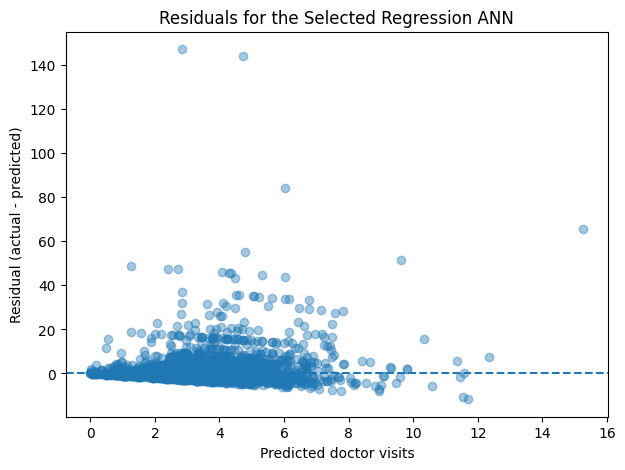

In [31]:
import matplotlib.pyplot as plt

residuals = y_test_reg - test_pred_reg

plt.figure(figsize=(7, 5))
plt.scatter(test_pred_reg, residuals, alpha=0.4)
plt.axhline(0, linestyle='--')
plt.xlabel('Predicted doctor visits')
plt.ylabel('Residual (actual - predicted)')
plt.title('Residuals for the Selected Regression ANN')
plt.show()

The residual plot shows that most prediction errors are relatively small for respondents with lower numbers of doctor visits, but the spread increases as predicted visits rise. Several large positive residuals indicate that the ANN substantially underpredicted respondents with very high healthcare use.

This pattern is consistent with the strongly right-skewed AH5 outcome. The selected log-target model reduced average absolute error, but extreme annual visit counts remained difficult to predict accurately.

In [32]:
race_labels = {
    1: 'Latino',
    2: 'Other single/multiple race',
    3: 'American Indian/Alaska Native',
    4: 'Asian',
    5: 'African American',
    6: 'White'
}

poverty_labels = {
    1: '0-99% FPL',
    2: '100-199% FPL',
    3: '200-299% FPL',
    4: '300% FPL and above'
}

insurance_labels = {
    1: 'Uninsured',
    2: 'Medicare & Medicaid',
    3: 'Medicare & others',
    4: 'Medicare only',
    5: 'Medicaid',
    7: 'Employment-based',
    8: 'Privately purchased',
    9: 'Other public'
}

region_labels = {
    1: 'Urban',
    2: 'Mixed',
    3: 'Suburban',
    4: 'Rural'
}

In [33]:
subgroups = {
    'Race/ethnicity': ('racehp2_p1', race_labels),
    'Poverty level': ('povll', poverty_labels),
    'Insurance type': ('instype', insurance_labels),
    'Urban/rural': ('ur_clrt4', region_labels)
}

for name, (col, labels) in subgroups.items():
    print(name)
    print(test[col].map(labels).value_counts())
    print()

Race/ethnicity
racehp2_p1
White                            1138
Latino                            342
Asian                             341
Other single/multiple race        325
African American                  151
American Indian/Alaska Native      43
Name: count, dtype: int64

Poverty level
povll
300% FPL and above    1404
100-199% FPL           358
0-99% FPL              300
200-299% FPL           278
Name: count, dtype: int64

Insurance type
instype
Employment-based       881
Medicare & others      735
Medicaid               261
Medicare & Medicaid    203
Medicare only           85
Privately purchased     84
Uninsured               66
Other public            25
Name: count, dtype: int64

Urban/rural
ur_clrt4
Urban       922
Suburban    751
Rural       419
Mixed       248
Name: count, dtype: int64



In [34]:
def classification_by_group(col, labels):
    rows = []

    for value in sorted(test[col].dropna().unique()):
        mask = test[col] == value

        y_group = y_test[mask]
        pred_group = test_pred[mask]
        prob_group = test_prob[mask]

        positive_rate = y_group.mean()

        precision = precision_score(
            y_group,
            pred_group,
            zero_division=0
        )

        recall = recall_score(
            y_group,
            pred_group,
            zero_division=0
        )

        f1 = f1_score(
            y_group,
            pred_group,
            zero_division=0
        )

        if y_group.nunique() == 2:
            roc_auc = roc_auc_score(
                y_group,
                prob_group
            )

            pr_auc = average_precision_score(
                y_group,
                prob_group
            )
        else:
            roc_auc = np.nan
            pr_auc = np.nan

        rows.append([
            labels.get(value, value),
            len(y_group),
            positive_rate,
            precision,
            recall,
            f1,
            roc_auc,
            pr_auc
        ])

    return pd.DataFrame(
        rows,
        columns=[
            'Group',
            'n',
            'Positive rate',
            'Precision',
            'Recall',
            'F1',
            'ROC-AUC',
            'PR-AUC'
        ]
    )

In [35]:
race_class = classification_by_group('racehp2_p1', race_labels)
poverty_class = classification_by_group('povll', poverty_labels)
insurance_class = classification_by_group('instype', insurance_labels)
region_class = classification_by_group('ur_clrt4', region_labels)

print("Race/ethnicity")
print(race_class.round(3))
print()

print("Poverty level")
print(poverty_class.round(3))
print()

print("Insurance type")
print(insurance_class.round(3))
print()

print("Urban/rural")
print(region_class.round(3))

Race/ethnicity
                           Group     n  Positive rate  Precision  Recall  \
0                         Latino   342          0.327      0.410   0.812   
1     Other single/multiple race   325          0.320      0.443   0.740   
2  American Indian/Alaska Native    43          0.372      0.375   0.375   
3                          Asian   341          0.214      0.283   0.493   
4               African American   151          0.298      0.440   0.733   
5                          White  1138          0.244      0.431   0.576   

      F1  ROC-AUC  PR-AUC  
0  0.545    0.670   0.453  
1  0.554    0.703   0.549  
2  0.375    0.590   0.437  
3  0.360    0.609   0.319  
4  0.550    0.735   0.532  
5  0.493    0.721   0.474  

Poverty level
                Group     n  Positive rate  Precision  Recall     F1  ROC-AUC  \
0           0-99% FPL   300          0.357      0.435   0.776  0.557    0.653   
1        100-199% FPL   358          0.360      0.455   0.775  0.573    0.686  

### Classification subgroup performance

Classification performance varied across the held-out subgroups. Recall was highest for Latino adults at 0.812 and lowest for American Indian/Alaska Native adults at 0.375, although the latter group included only 43 respondents. Asian adults also had lower recall and F1 than most other race/ethnicity groups.

Recall was above 0.74 for all three poverty groups below 300% of the Federal Poverty Level, compared with 0.516 among adults at 300% FPL and above. Insurance results also varied, with recall ranging from 0.444 for Medicare-only coverage to 0.876 for Medicaid. Across the urban/rural groups, F1 ranged from 0.450 in suburban areas to 0.595 in mixed areas.

These results describe model performance within the held-out test sample. Estimates for smaller groups are less stable and should be interpreted cautiously.

In [36]:
def regression_by_group(col, labels):
    rows = []

    for value in sorted(test[col].dropna().unique()):
        mask = test[col] == value

        y_group = y_test_reg[mask]
        pred_group = test_pred_reg[mask]

        mae = mean_absolute_error(
            y_group,
            pred_group
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_group,
                pred_group
            )
        )

        r2 = r2_score(
            y_group,
            pred_group
        )

        rows.append([
            labels.get(value, value),
            len(y_group),
            mae,
            rmse,
            r2
        ])

    return pd.DataFrame(
        rows,
        columns=[
            'Group',
            'n',
            'MAE',
            'RMSE',
            'R²'
        ]
    )

In [37]:
race_reg = regression_by_group(
    'racehp2_p1',
    race_labels
)

poverty_reg = regression_by_group(
    'povll',
    poverty_labels
)

insurance_reg = regression_by_group(
    'instype',
    insurance_labels
)

region_reg = regression_by_group(
    'ur_clrt4',
    region_labels
)

print("Race/ethnicity")
print(race_reg.round(3))
print()

print("Poverty level")
print(poverty_reg.round(3))
print()

print("Insurance type")
print(insurance_reg.round(3))
print()

print("Urban/rural")
print(region_reg.round(3))

Race/ethnicity
                           Group     n    MAE    RMSE     R²
0                         Latino   342  4.151  12.909 -0.007
1     Other single/multiple race   325  2.765   4.792  0.070
2  American Indian/Alaska Native    43  2.538   3.337 -0.094
3                          Asian   341  2.670   5.789 -0.012
4               African American   151  3.892   7.381 -0.012
5                          White  1138  3.931   7.747  0.035

Poverty level
                Group     n    MAE    RMSE     R²
0           0-99% FPL   300  4.292   8.754  0.068
1        100-199% FPL   358  4.668  12.799 -0.017
2        200-299% FPL   278  3.048   5.518  0.018
3  300% FPL and above  1404  3.272   6.687  0.032

Insurance type
                 Group    n    MAE    RMSE     R²
0            Uninsured   66  1.517   3.221  0.077
1  Medicare & Medicaid  203  5.411  13.702  0.006
2    Medicare & others  735  3.896   7.770 -0.023
3        Medicare only   85  3.729   7.623  0.103
4             Medicaid  261

### Regression subgroup performance

Regression error also varied across the held-out subgroups. Medicare and Medicaid respondents had the highest MAE at 5.411 visits, while uninsured respondents had the lowest at 1.517, although the uninsured group included only 66 test respondents. Employment-based insurance also had relatively low error, with an MAE of 2.959.

Among poverty groups, MAE was highest for adults at 100–199% FPL at 4.668 visits and lowest for adults at 200–299% FPL at 3.048. Latino respondents had the highest race/ethnicity MAE at 4.151 visits. Urban/rural differences were smaller, with MAE ranging from 3.448 in suburban areas to 3.714 in mixed areas.

R² was close to zero or negative for many subgroups, consistent with the limited amount of variation explained by the regression ANN overall. Smaller subgroup estimates should be interpreted cautiously.

### Subgroup uncertainty

Bootstrap intervals are used to show how stable selected subgroup performance estimates are within the held-out test sample. Classification bootstraps resample positive and negative cases separately within each subgroup so both classes remain represented. Recall and F1 intervals are reported for classification, and MAE intervals are reported for regression. These intervals describe uncertainty in model performance for the test respondents and are not CHIS population confidence intervals.

In [38]:
def bootstrap_classification(col, labels, n_boot=500):
    rows = []
    rng = np.random.default_rng(42)

    for value in sorted(test[col].dropna().unique()):
        idx = np.where(
            test[col].to_numpy() == value
        )[0]

        y_values = y_test.iloc[idx].to_numpy()

        positive_idx = idx[y_values == 1]
        negative_idx = idx[y_values == 0]

        if len(positive_idx) == 0 or len(negative_idx) == 0:
            continue

        recalls = []
        f1s = []

        for _ in range(n_boot):
            positive_sample = rng.choice(
                positive_idx,
                size=len(positive_idx),
                replace=True
            )

            negative_sample = rng.choice(
                negative_idx,
                size=len(negative_idx),
                replace=True
            )

            sample_idx = np.concatenate([
                positive_sample,
                negative_sample
            ])

            y_group = y_test.iloc[sample_idx]
            pred_group = test_pred[sample_idx]

            recalls.append(
                recall_score(
                    y_group,
                    pred_group,
                    zero_division=0
                )
            )

            f1s.append(
                f1_score(
                    y_group,
                    pred_group,
                    zero_division=0
                )
            )

        rows.append([
            labels.get(value, value),
            len(idx),
            np.mean(recalls),
            np.percentile(recalls, 2.5),
            np.percentile(recalls, 97.5),
            np.mean(f1s),
            np.percentile(f1s, 2.5),
            np.percentile(f1s, 97.5)
        ])

    return pd.DataFrame(
        rows,
        columns=[
            'Group',
            'n',
            'Recall',
            'Recall Low',
            'Recall High',
            'F1',
            'F1 Low',
            'F1 High'
        ]
    )

In [39]:
race_class_ci = bootstrap_classification('racehp2_p1', race_labels)
poverty_class_ci = bootstrap_classification('povll', poverty_labels)
insurance_class_ci = bootstrap_classification('instype', insurance_labels)
region_class_ci = bootstrap_classification('ur_clrt4', region_labels)

print("Race/ethnicity")
print(race_class_ci.round(3))
print()

print("Poverty level")
print(poverty_class_ci.round(3))
print()

print("Insurance type")
print(insurance_class_ci.round(3))
print()

print("Urban/rural")
print(region_class_ci.round(3))

Race/ethnicity
                           Group     n  Recall  Recall Low  Recall High  \
0                         Latino   342   0.813       0.732        0.875   
1     Other single/multiple race   325   0.742       0.663        0.827   
2  American Indian/Alaska Native    43   0.375       0.125        0.625   
3                          Asian   341   0.493       0.370        0.603   
4               African American   151   0.733       0.600        0.844   
5                          White  1138   0.575       0.518        0.633   

      F1  F1 Low  F1 High  
0  0.546   0.500    0.587  
1  0.555   0.504    0.607  
2  0.374   0.154    0.579  
3  0.360   0.291    0.435  
4  0.549   0.463    0.627  
5  0.493   0.451    0.534  

Poverty level
                Group     n  Recall  Recall Low  Recall High     F1  F1 Low  \
0           0-99% FPL   300   0.776       0.692        0.850  0.557   0.508   
1        100-199% FPL   358   0.772       0.690        0.845  0.572   0.521   
2        20

The bootstrap intervals were widest for several of the smaller subgroups. American Indian/Alaska Native respondents had a recall interval from 0.125 to 0.625, reflecting the small test sample of 43 respondents. Smaller insurance groups also produced wide intervals, particularly Other Public, Medicare only, uninsured, and privately purchased insurance.

The poverty-level pattern was more stable. Recall was 0.515 for adults at 300% FPL and above, with a bootstrap interval from 0.459 to 0.570. Recall exceeded 0.74 for each of the three lower-income groups, with intervals centered well above the estimate for the highest-income group. The intervals show which subgroup differences appear more stable within the held-out sample and which are more sensitive to sample size.

In [40]:
def bootstrap_regression(col, labels, n_boot=500):
    rows = []
    rng = np.random.default_rng(42)

    for value in sorted(test[col].dropna().unique()):
        idx = np.where(test[col].to_numpy() == value)[0]

        maes = []

        for _ in range(n_boot):
            sample_idx = rng.choice(idx, size=len(idx), replace=True)

            y_group = y_test_reg.iloc[sample_idx]
            pred_group = test_pred_reg[sample_idx]

            maes.append(
                mean_absolute_error(y_group, pred_group)
            )

        rows.append([
            labels.get(value, value),
            len(idx),
            np.mean(maes),
            np.percentile(maes, 2.5),
            np.percentile(maes, 97.5)
        ])

    return pd.DataFrame(
        rows,
        columns=['Group', 'n', 'MAE', 'MAE Low', 'MAE High']
    )

In [41]:
race_reg_ci = bootstrap_regression('racehp2_p1', race_labels)
poverty_reg_ci = bootstrap_regression('povll', poverty_labels)
insurance_reg_ci = bootstrap_regression('instype', insurance_labels)
region_reg_ci = bootstrap_regression('ur_clrt4', region_labels)

print("Race/ethnicity")
print(race_reg_ci.round(3))
print()

print("Poverty level")
print(poverty_reg_ci.round(3))
print()

print("Insurance type")
print(insurance_reg_ci.round(3))
print()

print("Urban/rural")
print(region_reg_ci.round(3))

Race/ethnicity
                           Group     n    MAE  MAE Low  MAE High
0                         Latino   342  4.195    3.040     5.694
1     Other single/multiple race   325  2.750    2.390     3.176
2  American Indian/Alaska Native    43  2.523    1.878     3.310
3                          Asian   341  2.650    2.172     3.189
4               African American   151  3.863    2.965     4.821
5                          White  1138  3.916    3.575     4.294

Poverty level
                Group     n    MAE  MAE Low  MAE High
0           0-99% FPL   300  4.306    3.469     5.261
1        100-199% FPL   358  4.704    3.637     5.983
2        200-299% FPL   278  3.041    2.576     3.591
3  300% FPL and above  1404  3.271    2.996     3.615

Insurance type
                 Group    n    MAE  MAE Low  MAE High
0            Uninsured   66  1.548    0.946     2.475
1  Medicare & Medicaid  203  5.369    3.975     7.173
2    Medicare & others  735  3.908    3.457     4.428
3        Medi

Bootstrap intervals for regression MAE varied considerably across insurance groups. Medicare and Medicaid had the highest point estimate at 5.369 visits, while uninsured respondents had the lowest at 1.548. Several smaller insurance groups had wide intervals, especially Other Public, Medicare only, privately purchased insurance, and uninsured respondents.

Differences across urban/rural groups were modest, with broadly overlapping intervals. Poverty-group MAE was higher for adults below 200% FPL than for the two higher-income groups, although the intervals still overlap. These intervals describe uncertainty in test-sample model error and should not be interpreted as population-level confidence intervals.

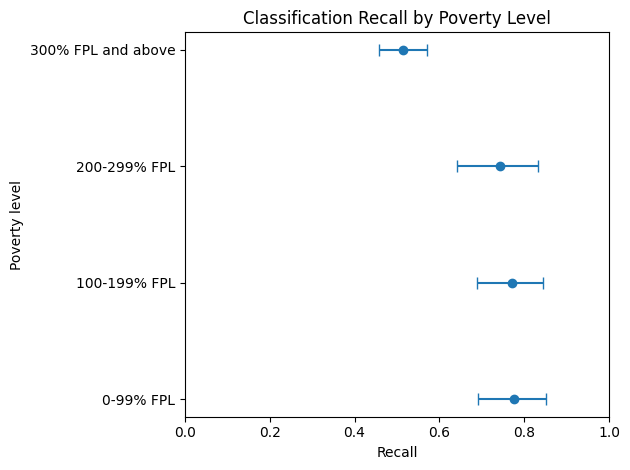

In [42]:
x = poverty_class_ci['Recall']
low = x - poverty_class_ci['Recall Low']
high = poverty_class_ci['Recall High'] - x

plt.errorbar(
    x,
    poverty_class_ci['Group'],
    xerr=[low, high],
    fmt='o',
    capsize=4
)

plt.xlabel('Recall')
plt.ylabel('Poverty level')
plt.title('Classification Recall by Poverty Level')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

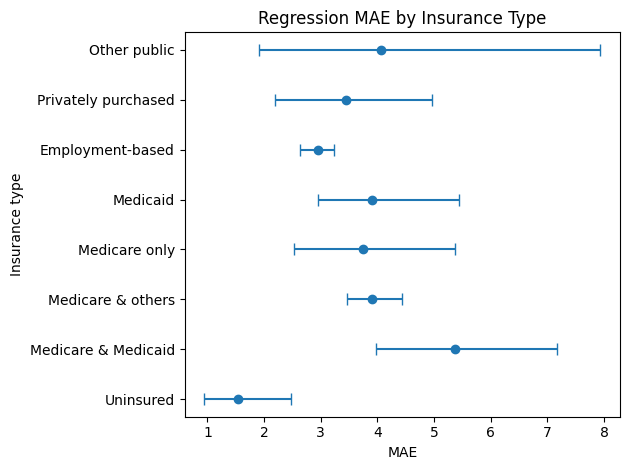

In [43]:
x = insurance_reg_ci['MAE']
low = x - insurance_reg_ci['MAE Low']
high = insurance_reg_ci['MAE High'] - x

plt.errorbar(
    x,
    insurance_reg_ci['Group'],
    xerr=[low, high],
    fmt='o',
    capsize=4
)

plt.xlabel('MAE')
plt.ylabel('Insurance type')
plt.title('Regression MAE by Insurance Type')
plt.tight_layout()
plt.show()

## Model interpretation

Permutation importance is used to examine how prediction performance changes when each predictor is shuffled. Classification importance is measured by the decrease in F1 for the selected 17-predictor model. Regression importance is measured by the increase in MAE for the selected 24-predictor model.

Larger positive values indicate that model performance worsened more when a predictor was disrupted. These results describe the fitted ANNs and do not establish causal relationships.

In [44]:
rng = np.random.default_rng(42)

base_f1 = f1_score(y_test, test_pred)

class_importance = []

for col in base_predictors:
    scores = []

    for _ in range(20):
        X_perm = X_test_base.copy()
        X_perm[col] = rng.permutation(X_perm[col].values)

        X_perm_prep = prep.transform(X_perm)

        prob = selected_classifier.predict(
            X_perm_prep,
            verbose=0
        ).ravel()

        pred = (prob >= 0.5).astype(int)

        scores.append(
            base_f1 - f1_score(y_test, pred)
        )

    class_importance.append([
        col,
        np.mean(scores),
        np.std(scores)
    ])

In [45]:
class_importance_df = pd.DataFrame(
    class_importance,
    columns=['Predictor', 'Importance', 'SD']
).sort_values('Importance', ascending=False)

class_importance_df['Predictor'] = (
    class_importance_df['Predictor']
    .map(predictor_labels)
)

print(class_importance_df.round(3))

              Predictor  Importance     SD
10               Asthma       0.084  0.008
11             Diabetes       0.038  0.006
7        General health       0.015  0.007
15        Poverty ratio       0.009  0.004
12  High blood pressure       0.007  0.004
8     Physical activity       0.005  0.004
6        Stable housing       0.003  0.002
1                Gender       0.003  0.005
9       Current smoking       0.003  0.001
0                   Age       0.002  0.007
4             Education      -0.001  0.004
14               Stroke      -0.001  0.001
16                  BMI      -0.001  0.004
2        Race/ethnicity      -0.002  0.006
5     Employment status      -0.003  0.004
13        Heart disease      -0.003  0.002
3           Urban/rural      -0.003  0.004


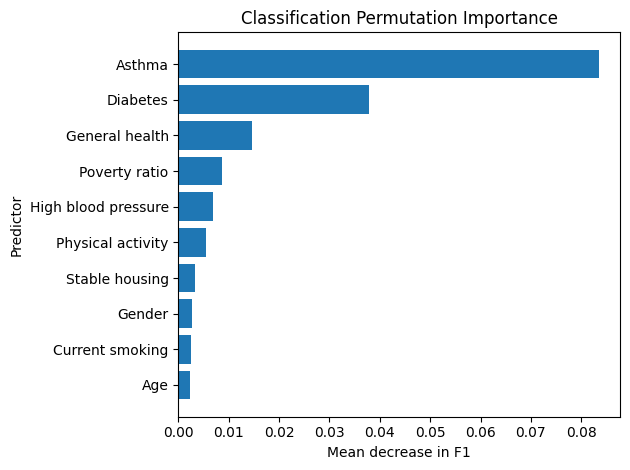

In [46]:
top_class = class_importance_df.head(10).sort_values('Importance')

plt.barh(
    top_class['Predictor'],
    top_class['Importance']
)

plt.xlabel('Mean decrease in F1')
plt.ylabel('Predictor')
plt.title('Classification Permutation Importance')
plt.tight_layout()
plt.show()

### Classification permutation importance

Permutation importance for the selected classification ANN was concentrated in a small number of predictors. Asthma produced the largest mean decrease in F1 when permuted at 0.084, followed by diabetes at 0.038. General health ranked third at 0.015.

Poverty ratio, high blood pressure, and physical activity had smaller positive contributions. Several predictors had importance values near zero or slightly below zero, indicating that permuting them did not consistently reduce held-out F1. These values describe the model's predictive dependence on each variable and should not be interpreted as causal effects.

In [47]:
rng = np.random.default_rng(42)

base_mae = mean_absolute_error(
    y_test_reg,
    test_pred_reg
)

reg_importance = []

for col in expanded_predictors:
    scores = []

    for _ in range(20):
        X_perm = X_test_reg_expanded.copy()
        X_perm[col] = rng.permutation(X_perm[col].values)

        X_perm_prep = prep_reg.transform(X_perm)

        pred_log = selected_regressor.predict(
            X_perm_prep,
            verbose=0
        ).ravel()

        pred = np.expm1(pred_log)

        scores.append(
            mean_absolute_error(y_test_reg, pred) - base_mae
        )

    reg_importance.append([
        col,
        np.mean(scores),
        np.std(scores)
    ])

In [48]:
reg_importance_df = pd.DataFrame(
    reg_importance,
    columns=['Predictor', 'Importance', 'SD']
).sort_values('Importance', ascending=False)

reg_importance_df['Predictor'] = (
    reg_importance_df['Predictor']
    .map(predictor_labels)
)

print(reg_importance_df.round(3))

                                       Predictor  Importance     SD
23                   Ease of getting needed care       0.100  0.011
7                                 General health       0.090  0.011
13                                 Heart disease       0.040  0.009
19                    Usual place for healthcare       0.031  0.005
0                                            Age       0.025  0.005
2                                 Race/ethnicity       0.023  0.005
5                              Employment status       0.018  0.004
1                                         Gender       0.016  0.005
20                         Medical-bill problems       0.014  0.008
10                                        Asthma       0.013  0.004
4                                      Education       0.012  0.005
11                                      Diabetes       0.011  0.004
12                           High blood pressure       0.009  0.004
21         Delayed or missed needed medical care

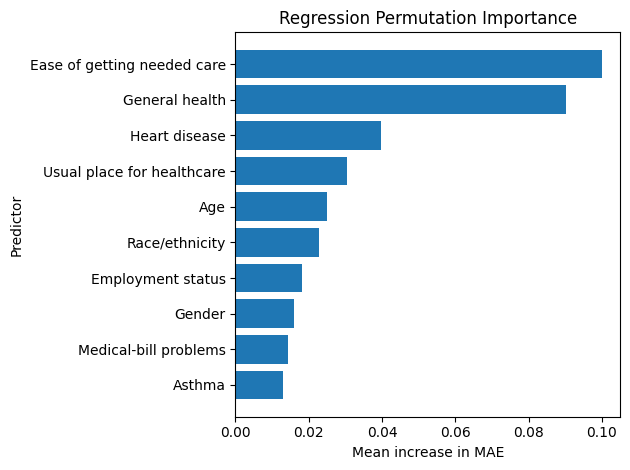

In [49]:
top_reg = reg_importance_df.head(10).sort_values('Importance')

plt.barh(
    top_reg['Predictor'],
    top_reg['Importance']
)

plt.xlabel('Mean increase in MAE')
plt.ylabel('Predictor')
plt.title('Regression Permutation Importance')
plt.tight_layout()
plt.show()

### Regression permutation importance

The selected regression ANN depended most strongly on ease of getting needed care and general health. Permuting these predictors increased MAE by about 0.100 and 0.090 visits, respectively. Heart disease and having a usual place for healthcare ranked next, followed by age and race/ethnicity.

Several of the added insurance and healthcare-access variables appeared among the more influential predictors, which is consistent with the expanded predictor set producing the lowest cross-validation MAE during tuning. Variables with importance values near zero or below zero did not consistently increase prediction error when permuted. Permutation importance reflects model dependence rather than causal influence.

### SHAP interpretation

SHAP values are calculated for a sample of test respondents to examine how encoded predictor values contribute to the selected classification ANN's output. A small training sample is used as the background distribution. The SHAP results describe the fitted model and should not be interpreted as causal effects.

In [50]:
import shap

rng = np.random.default_rng(42)

background_idx = rng.choice(
    X_train_prep.shape[0],
    size=100,
    replace=False
)

shap_idx = rng.choice(
    X_test_prep.shape[0],
    size=300,
    replace=False
)

background = X_train_prep[background_idx]
X_shap = X_test_prep[shap_idx]

feature_names = prep.get_feature_names_out()
feature_names = [
    name.replace('num__', '').replace('cat__', '')
    for name in feature_names
]

In [51]:
explainer = shap.GradientExplainer(
    selected_classifier,
    background
)

shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    shap_values = shap_values[0]

shap_values = np.asarray(shap_values)

if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 0]

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(300, 47))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(50, 47))']
  warnings.warn(msg)


/tmp/ipykernel_390/4045854597.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


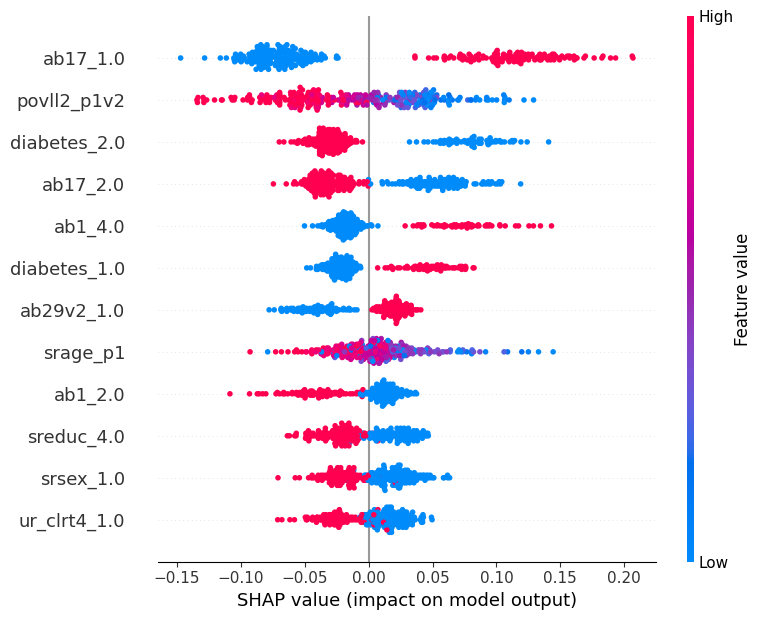

In [52]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    max_display=12
)

### SHAP results

The SHAP results were consistent with the permutation-importance analysis. Asthma-related features had the largest effects on the selected classification ANN, followed by poverty ratio, diabetes, and general-health features.

The encoded asthma and diabetes categories affected the model output in different directions depending on the category represented. Higher poverty-ratio values generally shifted predictions toward a lower probability of `not_controlled = 1`, while lower values tended to shift predictions upward. Age, education, gender, and urban/rural status had smaller contributions among the leading encoded features.

These results describe how the fitted ANN used the predictors for individual predictions and do not indicate causal effects.